# Reward Curves, Emotions and Satisfaction -- Game-Theoretic Setup

This notebook visualizes the reward shaping functions used in the game-theoretic
multi-agent environment: emotion mapping (linear vs sigmoid), personal satisfaction,
combined reward surfaces, and the effect of sweeping the empathy parameter alpha.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from collections import deque

sys.path.insert(0, os.path.abspath(os.path.join('..', 'game_theoretic_setup')))

from agent_policies_game_theoretic import SocialRewardCalculator, Agent

RATE_GRID = np.linspace(0.0, 1.0, 201)

## 1. Emotion Mapping: Linear vs Sigmoid

The `SocialRewardCalculator` maps a consumption rate in [0, 1] to an emotion
signal in [-1, 1], centered on a configurable threshold. Two smoothing modes
are available: `linear` and `sigmoid`.

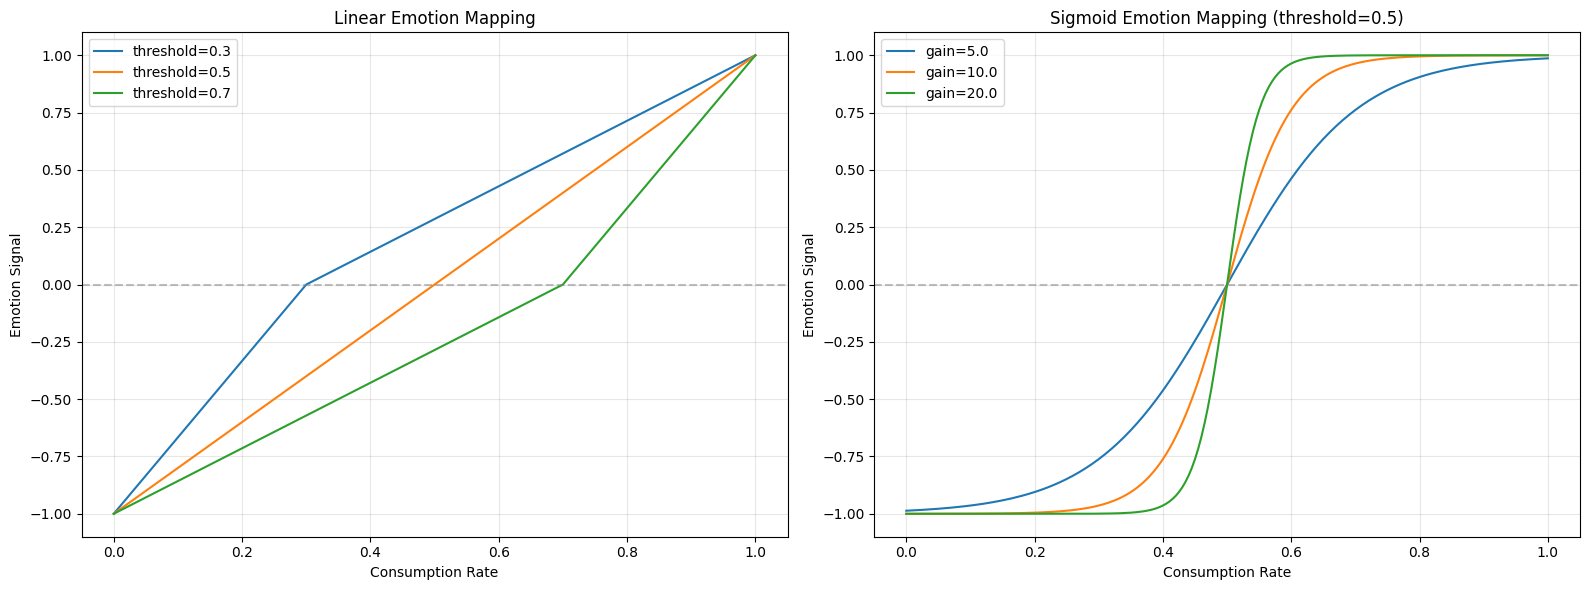

In [2]:
thresholds = [0.3, 0.5, 0.7]
sigmoid_gains = [5.0, 10.0, 20.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.set_title('Linear Emotion Mapping')
for t in thresholds:
    calc = SocialRewardCalculator(nb_agents=2, threshold=t, smoothing='linear')
    emotions = [calc.emotion_from_rate(r) for r in RATE_GRID]
    ax.plot(RATE_GRID, emotions, label=f'threshold={t}')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Consumption Rate')
ax.set_ylabel('Emotion Signal')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Sigmoid Emotion Mapping (threshold=0.5)')
for g in sigmoid_gains:
    calc = SocialRewardCalculator(nb_agents=2, threshold=0.5, smoothing='sigmoid', sigmoid_gain=g)
    emotions = [calc.emotion_from_rate(r) for r in RATE_GRID]
    ax.plot(RATE_GRID, emotions, label=f'gain={g}')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Consumption Rate')
ax.set_ylabel('Emotion Signal')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

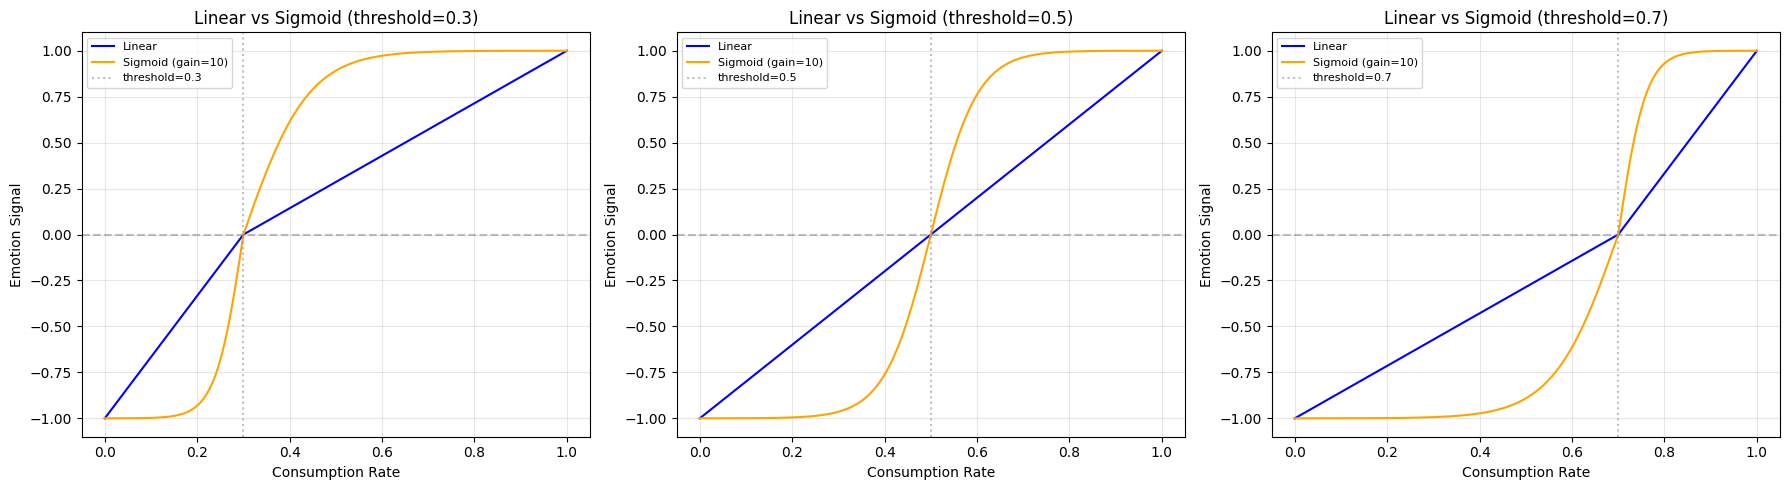

In [3]:
fig, axes = plt.subplots(1, len(thresholds), figsize=(6 * len(thresholds), 5))

for idx, t in enumerate(thresholds):
    ax = axes[idx]
    ax.set_title(f'Linear vs Sigmoid (threshold={t})')

    calc_lin = SocialRewardCalculator(nb_agents=2, threshold=t, smoothing='linear')
    calc_sig = SocialRewardCalculator(nb_agents=2, threshold=t, smoothing='sigmoid', sigmoid_gain=10.0)

    emo_lin = [calc_lin.emotion_from_rate(r) for r in RATE_GRID]
    emo_sig = [calc_sig.emotion_from_rate(r) for r in RATE_GRID]

    ax.plot(RATE_GRID, emo_lin, label='Linear', color='blue')
    ax.plot(RATE_GRID, emo_sig, label='Sigmoid (gain=10)', color='orange')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(t, color='gray', linestyle=':', alpha=0.5, label=f'threshold={t}')
    ax.set_xlabel('Consumption Rate')
    ax.set_ylabel('Emotion Signal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Personal Satisfaction as a Function of Beta and Consumption

Personal satisfaction is computed as:
`satisfaction = beta * last_meal + (1 - beta) * avg_meal_history`

Here we visualize how satisfaction varies with consumption rate for different beta values.

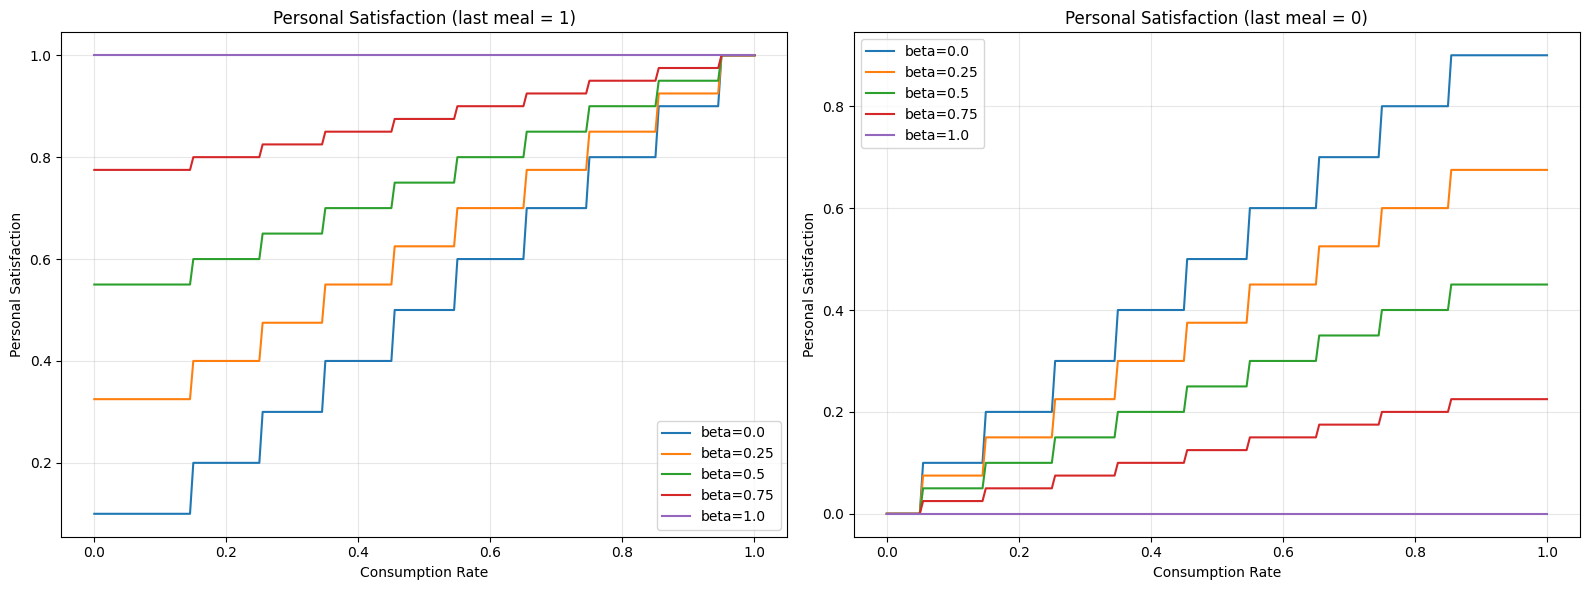

In [4]:
betas = [0.0, 0.25, 0.5, 0.75, 1.0]
memory_size = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.set_title('Personal Satisfaction (last meal = 1)')
for beta in betas:
    calc = SocialRewardCalculator(nb_agents=1, beta=beta)
    satisfactions = []
    for rate in RATE_GRID:
        agent = Agent(agent_id=0, memory_size=memory_size)
        n_meals = int(round(rate * memory_size))
        for j in range(memory_size - 1):
            agent.record_meal(j < (n_meals - 1), 1.0 if j < (n_meals - 1) else 0.0)
        agent.record_meal(True, 1.0)
        satisfactions.append(calc.calculate_personal_satisfaction(agent))
    ax.plot(RATE_GRID, satisfactions, label=f'beta={beta}')
ax.set_xlabel('Consumption Rate')
ax.set_ylabel('Personal Satisfaction')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Personal Satisfaction (last meal = 0)')
for beta in betas:
    calc = SocialRewardCalculator(nb_agents=1, beta=beta)
    satisfactions = []
    for rate in RATE_GRID:
        agent = Agent(agent_id=0, memory_size=memory_size)
        n_meals = int(round(rate * memory_size))
        for j in range(memory_size - 1):
            agent.record_meal(j < n_meals, 1.0 if j < n_meals else 0.0)
        agent.record_meal(False, 0.0)
        satisfactions.append(calc.calculate_personal_satisfaction(agent))
    ax.plot(RATE_GRID, satisfactions, label=f'beta={beta}')
ax.set_xlabel('Consumption Rate')
ax.set_ylabel('Personal Satisfaction')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Combined Reward Surface

The combined reward is:
`combined = (1 - alpha) * personal_satisfaction + alpha * others_avg_emotion`

We plot this as a heatmap and 3D surface for different alpha values.

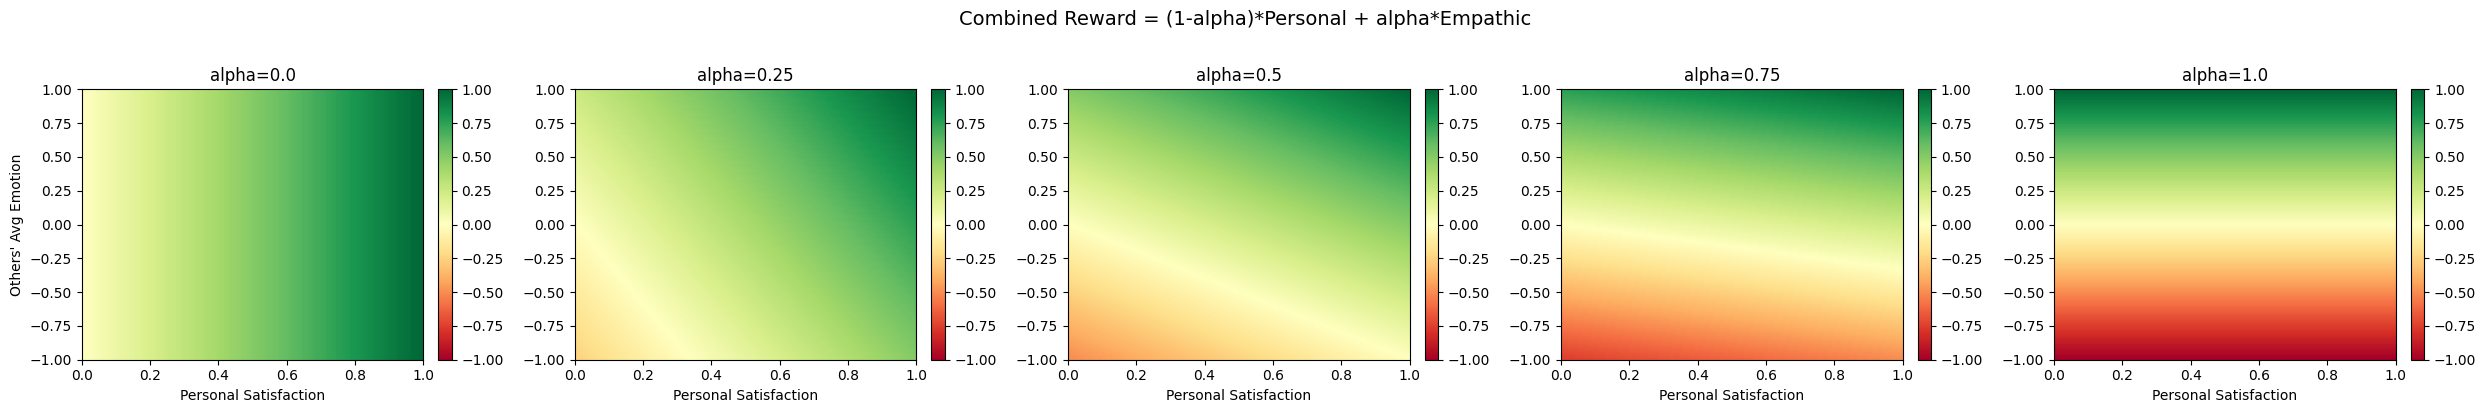

In [5]:
personal_grid = np.linspace(0.0, 1.0, 101)
emotion_grid = np.linspace(-1.0, 1.0, 101)
P, E = np.meshgrid(personal_grid, emotion_grid, indexing='xy')

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(alphas), figsize=(5 * len(alphas), 4))

for idx, alpha in enumerate(alphas):
    combined = (1 - alpha) * P + alpha * E
    ax = axes[idx]
    im = ax.imshow(
        combined, origin='lower', aspect='auto',
        extent=[0, 1, -1, 1], cmap='RdYlGn',
        vmin=-1, vmax=1
    )
    ax.set_title(f'alpha={alpha}')
    ax.set_xlabel('Personal Satisfaction')
    if idx == 0:
        ax.set_ylabel("Others' Avg Emotion")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Combined Reward = (1-alpha)*Personal + alpha*Empathic', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

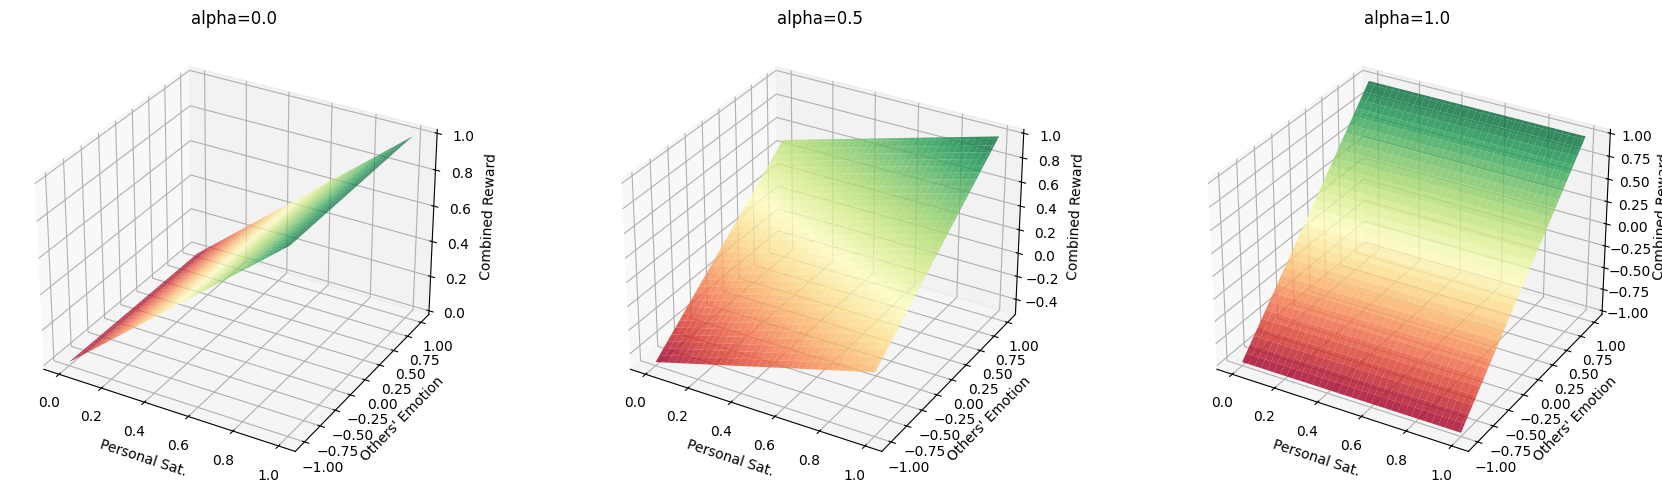

In [6]:
fig = plt.figure(figsize=(18, 5))

for idx, alpha in enumerate([0.0, 0.5, 1.0]):
    combined = (1 - alpha) * P + alpha * E
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.plot_surface(P, E, combined, cmap='RdYlGn', alpha=0.8, edgecolor='none')
    ax.set_xlabel('Personal Sat.')
    ax.set_ylabel("Others' Emotion")
    ax.set_zlabel('Combined Reward')
    ax.set_title(f'alpha={alpha}')

plt.tight_layout()
plt.show()

## 4. Alpha Sweep

For fixed personal satisfaction and others' average emotion scenarios,
sweep alpha from 0 to 1 to show the trade-off between selfish and empathic behavior.

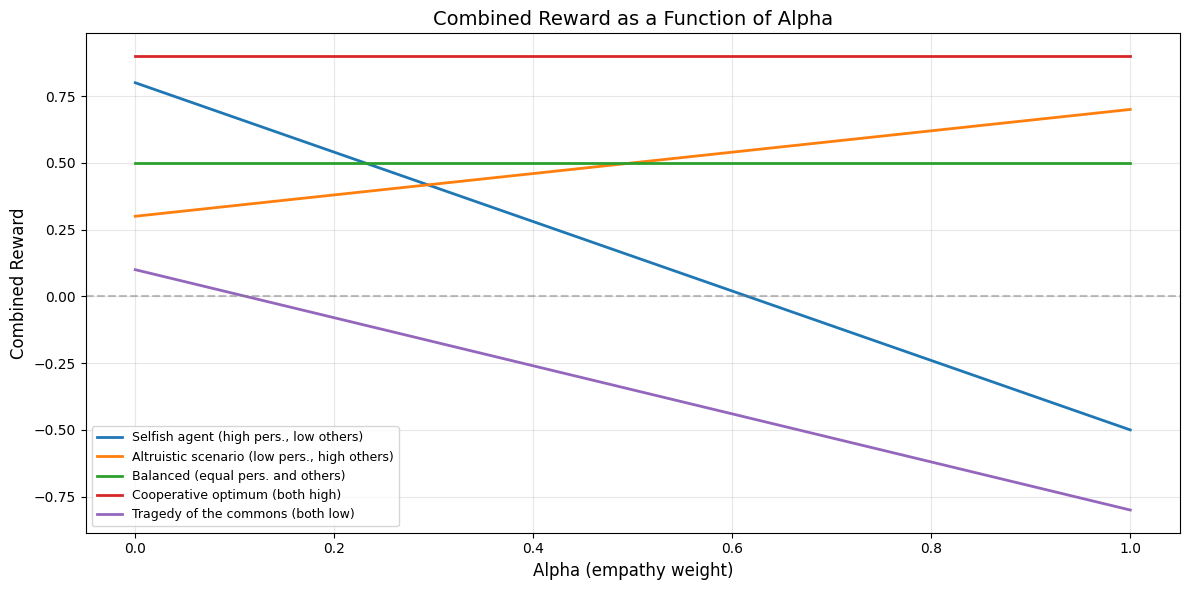

In [7]:
alpha_grid = np.linspace(0.0, 1.0, 201)

scenarios = [
    {'personal': 0.8, 'empathic': -0.5, 'label': 'Selfish agent (high pers., low others)'},
    {'personal': 0.3, 'empathic': 0.7, 'label': 'Altruistic scenario (low pers., high others)'},
    {'personal': 0.5, 'empathic': 0.5, 'label': 'Balanced (equal pers. and others)'},
    {'personal': 0.9, 'empathic': 0.9, 'label': 'Cooperative optimum (both high)'},
    {'personal': 0.1, 'empathic': -0.8, 'label': 'Tragedy of the commons (both low)'},
]

fig, ax = plt.subplots(figsize=(12, 6))

for sc in scenarios:
    combined = (1 - alpha_grid) * sc['personal'] + alpha_grid * sc['empathic']
    ax.plot(alpha_grid, combined, label=sc['label'], linewidth=2)

ax.set_xlabel('Alpha (empathy weight)', fontsize=12)
ax.set_ylabel('Combined Reward', fontsize=12)
ax.set_title('Combined Reward as a Function of Alpha', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

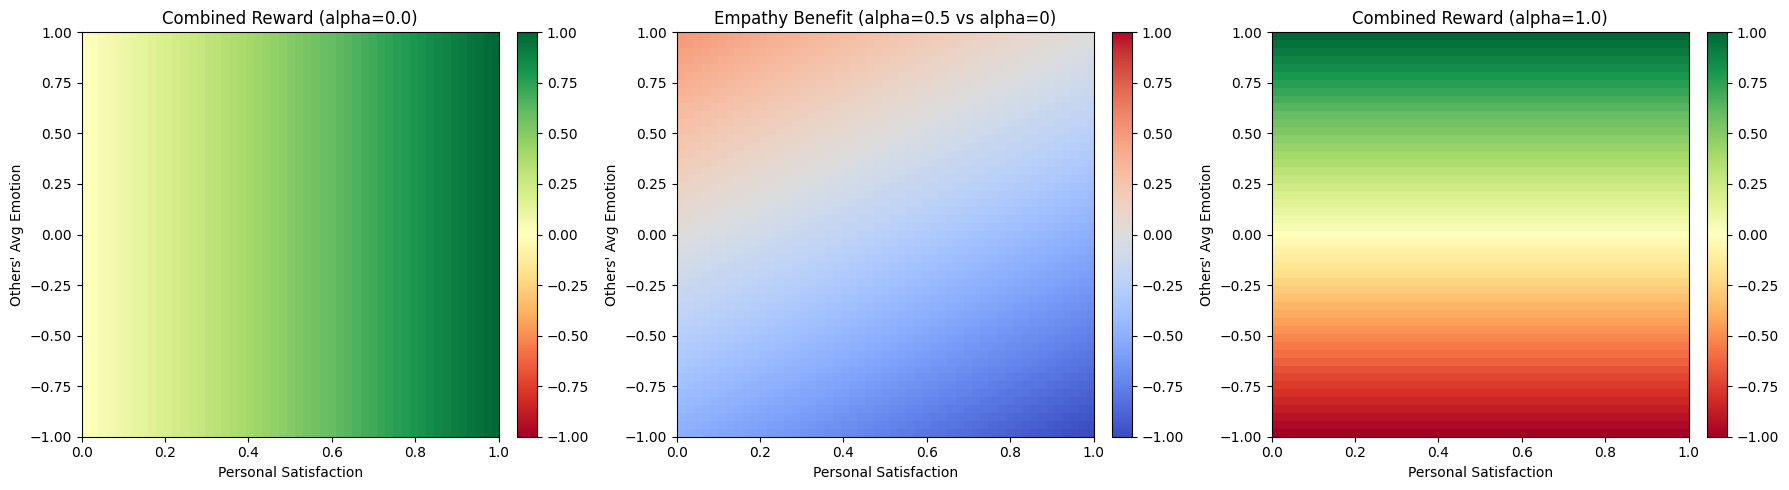

: 

In [ ]:
personal_vals = np.linspace(0.0, 1.0, 51)
empathic_vals = np.linspace(-1.0, 1.0, 51)
P2, E2 = np.meshgrid(personal_vals, empathic_vals, indexing='xy')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, alpha in enumerate([0.0, 0.5, 1.0]):
    combined = (1 - alpha) * P2 + alpha * E2
    optimal_alpha = np.where(P2 > E2, 0.0, 1.0)
    if alpha == 0.5:
        benefit = combined - P2
        ax = axes[idx]
        im = ax.imshow(
            benefit, origin='lower', aspect='auto',
            extent=[0, 1, -1, 1], cmap='coolwarm',
            vmin=-1, vmax=1
        )
        ax.set_title(f'Empathy Benefit (alpha={alpha} vs alpha=0)')
        ax.set_xlabel('Personal Satisfaction')
        ax.set_ylabel("Others' Avg Emotion")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax = axes[idx]
        im = ax.imshow(
            combined, origin='lower', aspect='auto',
            extent=[0, 1, -1, 1], cmap='RdYlGn',
            vmin=-1, vmax=1
        )
        ax.set_title(f'Combined Reward (alpha={alpha})')
        ax.set_xlabel('Personal Satisfaction')
        ax.set_ylabel("Others' Avg Emotion")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()